In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import shap
import joblib
from lib.streamlit_api import (
    load_dataset
)
from lib.xgboost_predictor import (
    XGBPlayerPerformancePredictor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import (
    MinMaxScaler
)

# Preprocessing

In [27]:
df = load_dataset(path="data/players_history.csv")
df.columns

Index(['season', 'player', 'team', 'competition', 'nationality', 'position',
       'age', 'birth_year', 'appearances', 'starts', 'minutes', 'nineties',
       'goals_per90', 'assists_per90', 'goals_assists_per90',
       'non_penalty_goals_per90', 'non_penalty_goals_assists_per90',
       'penalty_attempts_per90', 'yellow_cards_per90', 'red_cards_per90',
       'shots_on_target_pct', 'shots_per90', 'shots_on_target_per90',
       'goals_per_shot', 'goals_per_shot_on_target', 'interceptions_per90',
       'tackles_won_per90', 'goals_against_per90',
       'shots_on_target_against_per90', 'saves_per90', 'save_pct',
       'wins_per90', 'draws_per90', 'losses_per90', 'clean_sheets_per90',
       'clean_sheet_pct', 'keeper_penalty_attempts_per90',
       'penalties_allowed_per90', 'penalties_saved_per90',
       'penalties_missed_per90'],
      dtype='object')

In [28]:
numerical_cols = [
    "age",
    "birth_year",

    "appearances",
    "starts",
    "minutes",

    "goals_per90",
    "assists_per90",
    "goals_assists_per90",

    "non_penalty_goals_per90",
    "non_penalty_goals_assists_per90",

    "shots_per90",
    "shots_on_target_per90",

    "goals_per_shot",
    "goals_per_shot_on_target",

    "yellow_cards_per90",
    "red_cards_per90",

    "interceptions_per90",
    "tackles_won_per90",

    "wins_per90",
    "draws_per90",
    "losses_per90",
]

to_drop_cols = [
    "player",
    "normalized_name",
    "id",

    # Fantacalcio fields
    "Id",
    "R",
    "RM",
    "Nome",
    "Squadra",
    "Qt.A",
    "Qt.I",
    "Diff.",
    "Qt.A M",
    "Qt.I M",
    "Diff.M",
    "FVM",
    "FVM M",

    # We don't want to predict golkeepers
    "clean_sheets_per90",
    "clean_sheet_pct",
    "penalties_saved_per90",
    "goals_against_per90",
    "saves_per90",
    "save_pct",

    # To be handled/transformed
    "team",
    "competition", # one-hot
    "nationality",
    "position" # one-hot
]

In [29]:
df = df.copy()

# Remove columns
df = df.drop(columns=[c for c in to_drop_cols if c in df.columns and c not in ["player", "season"]])

# Columns to use (player and season won't be used for the training)
available_num_cols = [c for c in numerical_cols if c in df.columns]
df = df[["player", "season"] + available_num_cols]

# Ensure that they will be numeric
for col in available_num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Initialize absent values
df = df.fillna(0)
df.columns

Index(['player', 'season', 'age', 'birth_year', 'appearances', 'starts',
       'minutes', 'goals_per90', 'assists_per90', 'goals_assists_per90',
       'non_penalty_goals_per90', 'non_penalty_goals_assists_per90',
       'shots_per90', 'shots_on_target_per90', 'goals_per_shot',
       'goals_per_shot_on_target', 'yellow_cards_per90', 'red_cards_per90',
       'interceptions_per90', 'tackles_won_per90', 'wins_per90', 'draws_per90',
       'losses_per90'],
      dtype='object')

# Training and Evaluation of XGBoost model

In [30]:
grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.005, 0.01, 0.02],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 5, 10]
}
grid = {
    "n_estimators": [200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.02],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [2, 3, 4],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 5]
}

n_combinations = math.prod(len(values) for values in grid.values())
n_combinations

864

In [ ]:
target_feature = "goals_per90"

window_size_list = [1, 2, 3, 4, 5]
predictors = {}

for window_size_i in window_size_list:
    predictor = XGBPlayerPerformancePredictor(
        player_col="player",
        season_col="season",
        target_col=target_feature,
        window_size=window_size_i,
        drop_cols=None,
        param_grid=grid
    )

    X, y = predictor.build_temporal_dataset(df)
    X_train, X_test, y_train, y_test = predictor.temporal_split(X, y)

    predictor.train(X_train, y_train, verbose=0)
    results = predictor.evaluate(X_test, y_test)

    # Baseline predictions
    predictions = np.mean(y_train)
    MAE_baseline = mean_absolute_error(y_test, np.full_like(y_test, predictions))

    predictors[window_size_i] = (predictor, X_train, y_train, X_test, y_test, results, MAE_baseline)

predictor.model

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 5, 'subsample': 0.7}
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.02, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.02, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.7}
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

# Comparison with different *windows_size* values

In [32]:
def highlight_baseline(row):
    if row["MAE"] < row["MAE_baseline"]:
        return ["background-color: green"] * len(row)
    else:
        return ["background-color: coral"] * len(row)

# Build the table to show the results
results_table = []
for window_size, (predictor, X_train, y_train, X_test, y_test, results, mae_baseline) in predictors.items():
    results_table.append(
        {
            "window_size": window_size,
            "MAE": results["MAE"],
            "RMSE": results["RMSE"],
            "R2": results["R2"],
            "MAE_baseline": mae_baseline
        }
    )

results_df = pd.DataFrame(results_table).sort_values(by="window_size")
results_df.style.apply(highlight_baseline, axis=1)

,window_size,MAE,RMSE,R2,MAE_baseline
0,1,0.085218,0.133026,0.467764,0.133580
1,2,0.082988,0.133858,0.494341,0.135329
2,3,0.082654,0.134956,0.503970,0.136560
3,4,0.082662,0.130530,0.534926,0.138112
4,5,0.088045,0.140635,0.504762,0.142858


# Best model selection
Based on the score, computed as weighted sum of the different errors.

In [33]:
# Normalization MAE e RMSE
scaler = MinMaxScaler()
results_df[["MAE_norm", "RMSE_norm"]] = scaler.fit_transform(results_df[["MAE", "RMSE"]].copy())

# Normalization R2 (has to be inverted because is better when is higher)
results_df["R2_norm"] = 1 - ((results_df["R2"] - results_df["R2"].min()) / (results_df["R2"].max() - results_df["R2"].min()))

# Compute the score for each window_size
w = [0, 0.6, 0.4]
results_df["score"] = (w[0] * results_df["MAE_norm"]) + (w[1] * results_df["RMSE_norm"]) + (w[2] * results_df["R2_norm"])

# Find the best predictor based on the score
sorted_results_df = results_df.sort_values(by="score", ascending=True)
best_window = sorted_results_df.iloc[0]["window_size"]

print(f"Best window size: {int(best_window)}")
sorted_results_df

Best window size: 4


,window_size,MAE,RMSE,R2,MAE_baseline,MAE_norm,RMSE_norm,R2_norm,score
3,4,0.082662,0.130530,0.534926,0.138112,0.001382,0.000000,0.000000,0.000000
1,2,0.082988,0.133858,0.494341,0.135329,0.061974,0.329394,0.604290,0.439353
2,3,0.082654,0.134956,0.503970,0.136560,0.000000,0.437969,0.460921,0.447150
0,1,0.085218,0.133026,0.467764,0.133580,0.475547,0.247028,1.000000,0.548217
4,5,0.088045,0.140635,0.504762,0.142858,1.000000,1.000000,0.449131,0.779652


In [34]:
print(f"\nBest parameters: {predictors[best_window][0].model.get_params()}\n")


Best parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.02, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': 2, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 5, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}



# Plots analysis

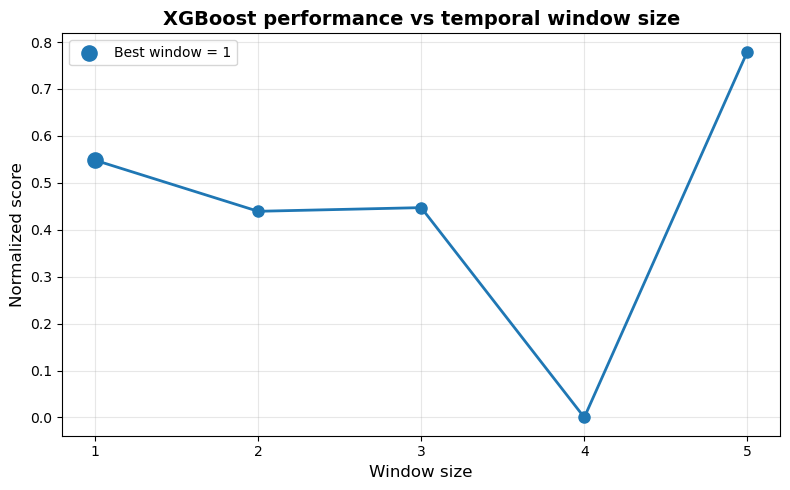

In [35]:
best_window_size = results_df.loc[0, "window_size"]
best_score = results_df.loc[0, "score"]

plt.figure(figsize=(8, 5))
plt.plot(
    results_df["window_size"],
    results_df["score"],
    marker="o",
    linewidth=2,
    markersize=8
)
plt.scatter(
    best_window_size,
    best_score,
    s=120,
    zorder=3,
    label=f"Best window = {best_window_size}"
)
plt.xlabel(
    "Window size",
    fontsize=12
)
plt.ylabel(
    "Normalized score",
    fontsize=12
)
plt.title(
    "XGBoost performance vs temporal window size",
    fontsize=14,
    fontweight="bold"
)
plt.xticks(results_df["window_size"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

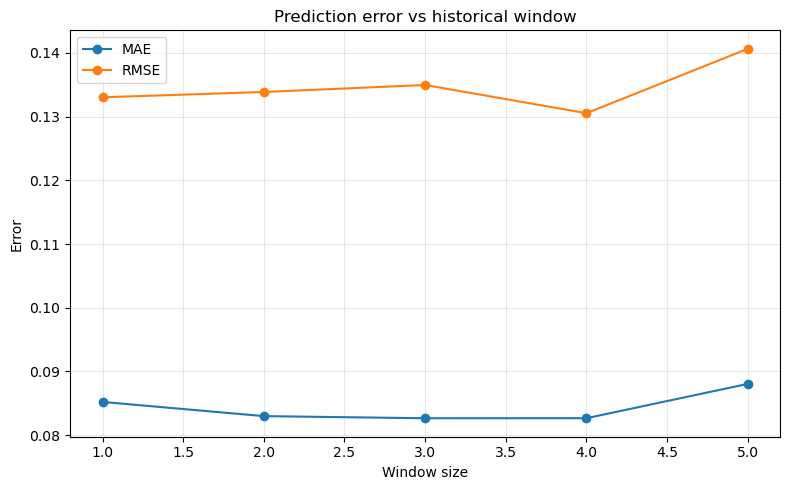

In [36]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(results_df["window_size"], results_df["MAE"], marker="o", label="MAE")
ax.plot(results_df["window_size"], results_df["RMSE"], marker="o", label="RMSE")

ax.set_xlabel("Window size")
ax.set_ylabel("Error")
ax.set_title("Prediction error vs historical window")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Features importances

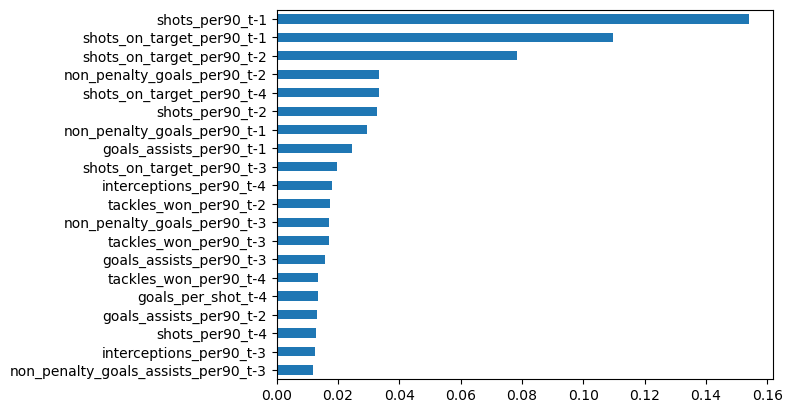

In [37]:
best_predictor = predictors[best_window][0]
best_X_train = predictors[best_window][1]

importance = pd.Series(
    best_predictor.model.feature_importances_,
    index=best_X_train.columns
)
importance.sort_values().tail(20).plot(kind="barh")
plt.show()

# Testing

In [38]:
X_train = predictors[best_window][1]
y_train = predictors[best_window][2]
X_test = predictors[best_window][3]
y_test = predictors[best_window][4]

y_pred = best_predictor.predict(X_test)

test_results_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "error": abs(y_test - y_pred)
})
test_results_df.head()

,actual,predicted,error
4588,0.43,0.274975,0.155025
4589,0.43,0.539412,0.109412
4590,0.35,0.059178,0.290822
4591,0.00,0.033309,0.033309
4592,0.35,0.265923,0.084077


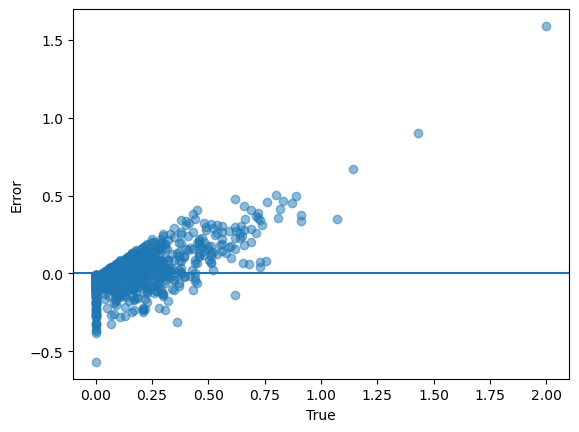

In [39]:
plt.scatter(
    y_test,
    y_test - y_pred,
    alpha=0.5
)
plt.axhline(0)
plt.xlabel("True")
plt.ylabel("Error")
plt.show()

# Explainability with SHAP

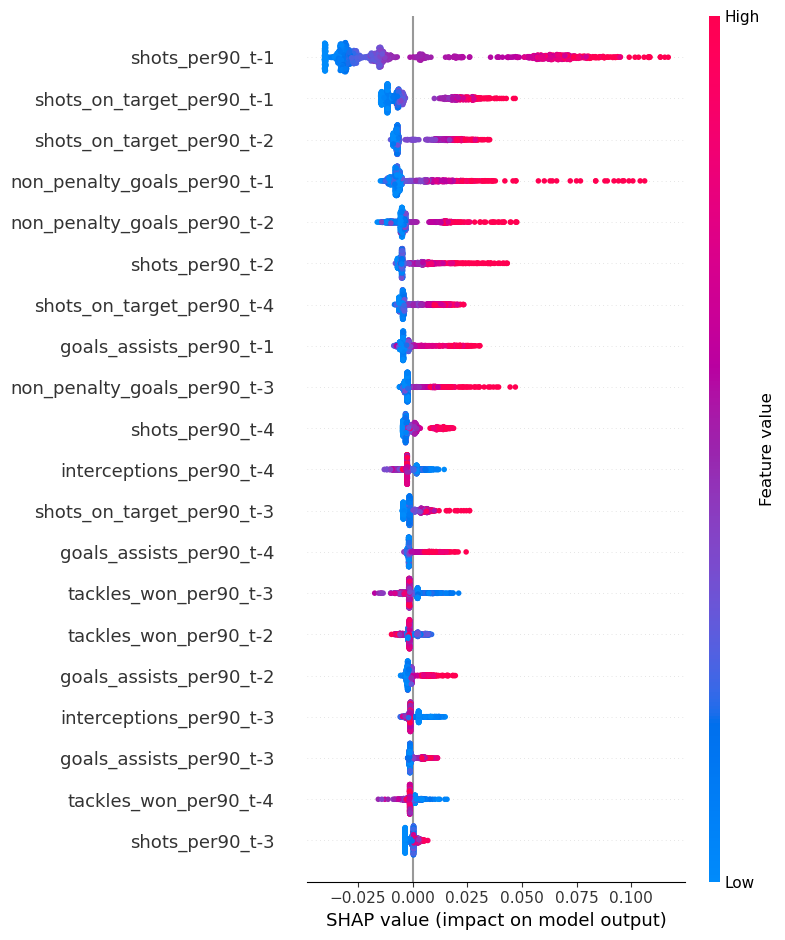

In [40]:
explainer = shap.TreeExplainer(best_predictor.model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

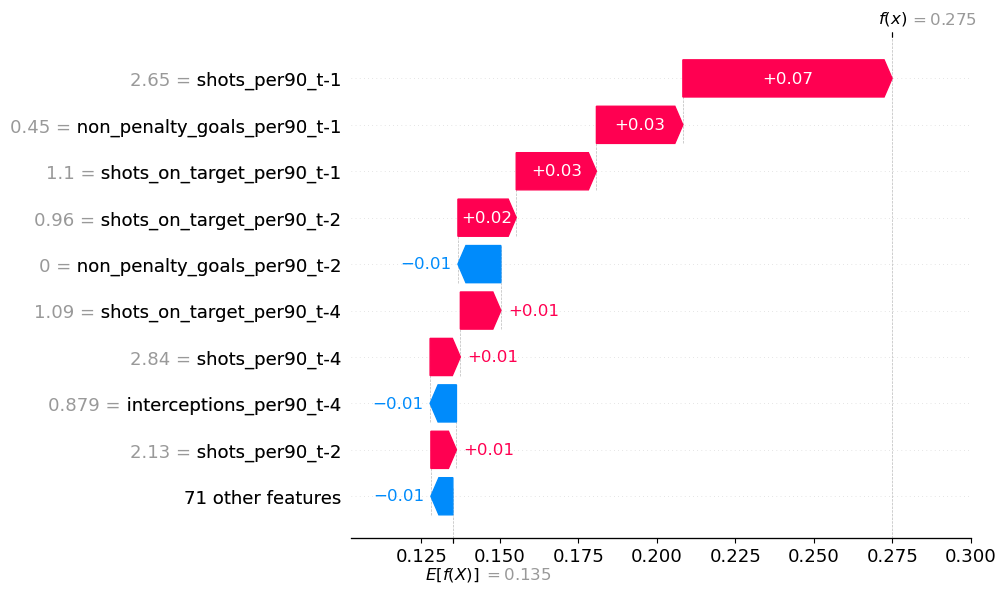

In [41]:
# e.g. to analize a specific player (in this case the first player in the test set)
idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=X_test.columns
    )
)

# Store the model and the explainer

In [ ]:
joblib.dump(
    {
        "model": best_predictor.model,
        "explainer": explainer,
        "features": X_train.columns.tolist(),
        "window_size": best_window_size,
        "RMSE": sorted_results_df.iloc[0]['RMSE'],
        "MAE": sorted_results_df.iloc[0]['MAE'],
    },
    f"models/xgb_{target_feature}.pkl"
)

['models/xgb_goals_per90.pkl']

Exception ignored in: <function ResourceTracker.__del__ at 0x106dc18a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106fd18a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1068318a0>
Traceback (most recent call last